In [61]:
import pandas as pd
import sqlite3
from pandas.plotting import scatter_matrix

In [62]:
df = pd.read_csv('../data/ab-test.csv')

In [63]:
df

,uid,diff,time,group
0,user_1,-103.333333,after,test
1,user_1,-6.000000,before,test
2,user_18,-10.000000,after,test
3,user_18,-3.500000,before,test
4,user_19,-82.333333,after,test
5,user_19,-148.000000,before,test
6,user_21,-78.500000,after,test
7,user_21,-112.500000,before,test
8,user_25,-127.500000,after,test
9,user_25,-69.333333,before,test


In [64]:
conn = sqlite3.connect('../data/checking-logs.sqlite')

In [65]:
pd.read_sql('SELECT name FROM sqlite_master WHERE type="table";', conn)

,name
0,pageviews
1,checker
2,deadlines
3,datamart
4,test


In [66]:
pd.read_sql('SELECT * FROM checker LIMIT 2;', conn)

,index,status,success,timestamp,numTrials,labname,uid
0,0,checking,0,2020-04-16 21:12:50.740474,5,None,admin_1
1,1,ready,0,2020-04-16 21:12:54.708365,5,code_rvw,admin_1


In [67]:
query = '''
CREATE TABLE datamart AS
SELECT
    c.uid,
    c.labname,
    MIN(c.timestamp) AS first_commit_ts,
    MIN(p.datetime) AS first_view_ts
FROM
    checker c
LEFT JOIN
    pageviews p
ON
    c.uid = p.uid
WHERE
    c.status = 'ready'
    AND c.numTrials = 1
    AND c.labname IN ('laba04', 'laba04s', 'laba05', 'laba06', 'laba06s', 'project1')
    AND c.uid LIKE 'user_%'
GROUP BY
    c.uid, c.labname
'''

In [68]:
conn.execute('DROP TABLE IF EXISTS datamart;')

In [69]:
conn.execute(query)

In [70]:
datamart = pd.read_sql('SELECT * FROM datamart', conn)

In [71]:
datamart['first_commit_ts'] = pd.to_datetime(datamart['first_commit_ts'])
datamart['first_view_ts'] = pd.to_datetime(datamart['first_view_ts'])

In [72]:
test = datamart[datamart['first_view_ts'].notnull()].copy()

In [73]:
test.to_sql('test', conn, if_exists='replace', index=False)

59

In [74]:
query = '''
WITH average_diffs AS (
SELECT
    t.uid,
    AVG((d.deadlines - strftime('%s', t.first_commit_ts)) / 3600.0) AS avg_diff
FROM
    test t
JOIN
    deadlines d
ON
    t.labname = d.labs
WHERE
    t.first_view_ts IS NOT NULL
    AND t.labname != 'project1'
GROUP BY
    uid
),
user_pageviews AS (
SELECT
    uid,
    COUNT(*) as pageviews
FROM
    pageviews
WHERE
    uid LIKE 'user_%'
GROUP BY
    uid
),
user_commits AS (
SELECT
    uid,
    COUNT(*) AS num_commits
FROM
    checker
WHERE
    uid LIKE 'user_%'
    AND labname != 'project1'
GROUP BY
    uid
)
SELECT
    d.uid,
    p.pageviews,
    c.num_commits,
    d.avg_diff
FROM
    average_diffs d
LEFT JOIN
    user_pageviews p
ON
    d.uid = p.uid
LEFT JOIN
    user_commits c
ON
    d.uid = c.uid;
'''

In [75]:
df = pd.read_sql(query, conn)

array([[<AxesSubplot: xlabel='avg_diff', ylabel='avg_diff'>,
        <AxesSubplot: xlabel='pageviews', ylabel='avg_diff'>,
        <AxesSubplot: xlabel='num_commits', ylabel='avg_diff'>],
       [<AxesSubplot: xlabel='avg_diff', ylabel='pageviews'>,
        <AxesSubplot: xlabel='pageviews', ylabel='pageviews'>,
        <AxesSubplot: xlabel='num_commits', ylabel='pageviews'>],
       [<AxesSubplot: xlabel='avg_diff', ylabel='num_commits'>,
        <AxesSubplot: xlabel='pageviews', ylabel='num_commits'>,
        <AxesSubplot: xlabel='num_commits', ylabel='num_commits'>]],
      dtype=object)

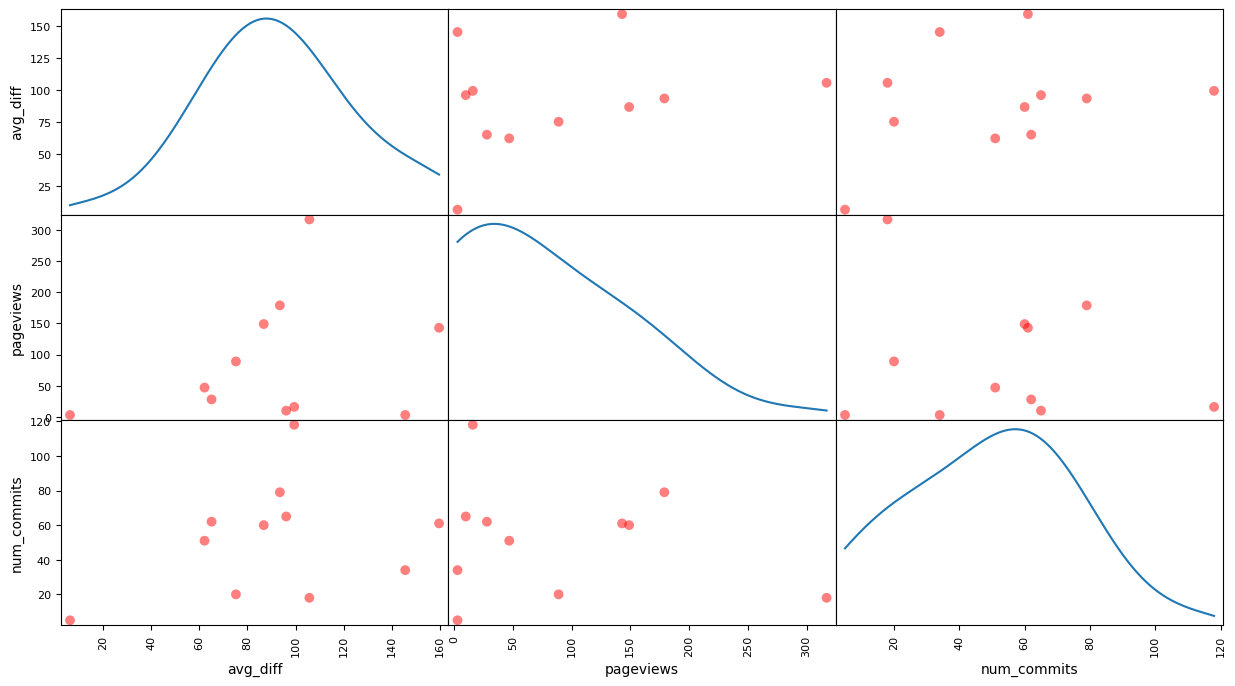

In [76]:
scatter_matrix(
    df[['avg_diff', 'pageviews', 'num_commits']],
    figsize=(15,8),
    color='red',
    diagonal='kde',
    s=200,
    hist_kwds={'linewidth': 3}
)

In [77]:
conn.close()

## Which user has the most commits on Tue?

## Can we say that if a user has a low number of pageviews then they likely have a low number of commits?” The answer: yes or no.

Answer: NO.

## Can we say that if a user has a low number of pageviews then they likely have a small average difference between the first commit and the lab deadline?

Answer: NO.

## Can we say that there are many users with a low number of commits and a few with a high number of commits

Answer: YES.

## Can we say that there are many users with a small average difference and a few with a large average difference?

Answer: NO.